In [66]:
# DC Housing Market Model Comparison
# This script implements and compares multiple modeling approaches
# for predicting DC housing price changes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Linear models
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Tree-based models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

# Time series models
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# 1. Data Loading and Preparation

In [67]:
print("==== DC HOUSING MARKET MODEL COMPARISON ====")

# Load the clean dataset (for linear models)
df_clean = pd.read_csv('dc_housing_modeling_features_clean.csv', parse_dates=['Date'], index_col='Date')

# Load the imputed dataset (for tree-based models)
df_partial = pd.read_csv('dc_housing_modeling_features_partial.csv', parse_dates=['Date'], index_col='Date')

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Imputed dataset shape: {df_partial.shape}")
print(f"Clean dataset time range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"Imputed dataset time range: {df_partial.index.min()} to {df_partial.index.max()}")

# Define X and y for clean dataset
X_clean = df_clean.drop('ZHVI_pct_change', axis=1)
y_clean = df_clean['ZHVI_pct_change']

# Define X and y for imputed dataset
X_partial = df_partial.drop('ZHVI_pct_change', axis=1)
y_partial = df_partial['ZHVI_pct_change']

==== DC HOUSING MARKET MODEL COMPARISON ====
Clean dataset shape: (89, 22)
Imputed dataset shape: (100, 36)
Clean dataset time range: 2001-04-01 00:00:00 to 2023-04-01 00:00:00
Imputed dataset time range: 2000-01-01 00:00:00 to 2024-10-01 00:00:00


# 2. Linear Models Implementation and Evaluation


===== RIDGE REGRESSION =====
Best alpha: 72.7
Ridge Regression Cross-validation Results:
RMSE: 1.44 (±0.02)
MAE: 1.04 (±0.08)
R²: -0.203 (±0.169)
Directional Accuracy: 75.86% (±10.34%)


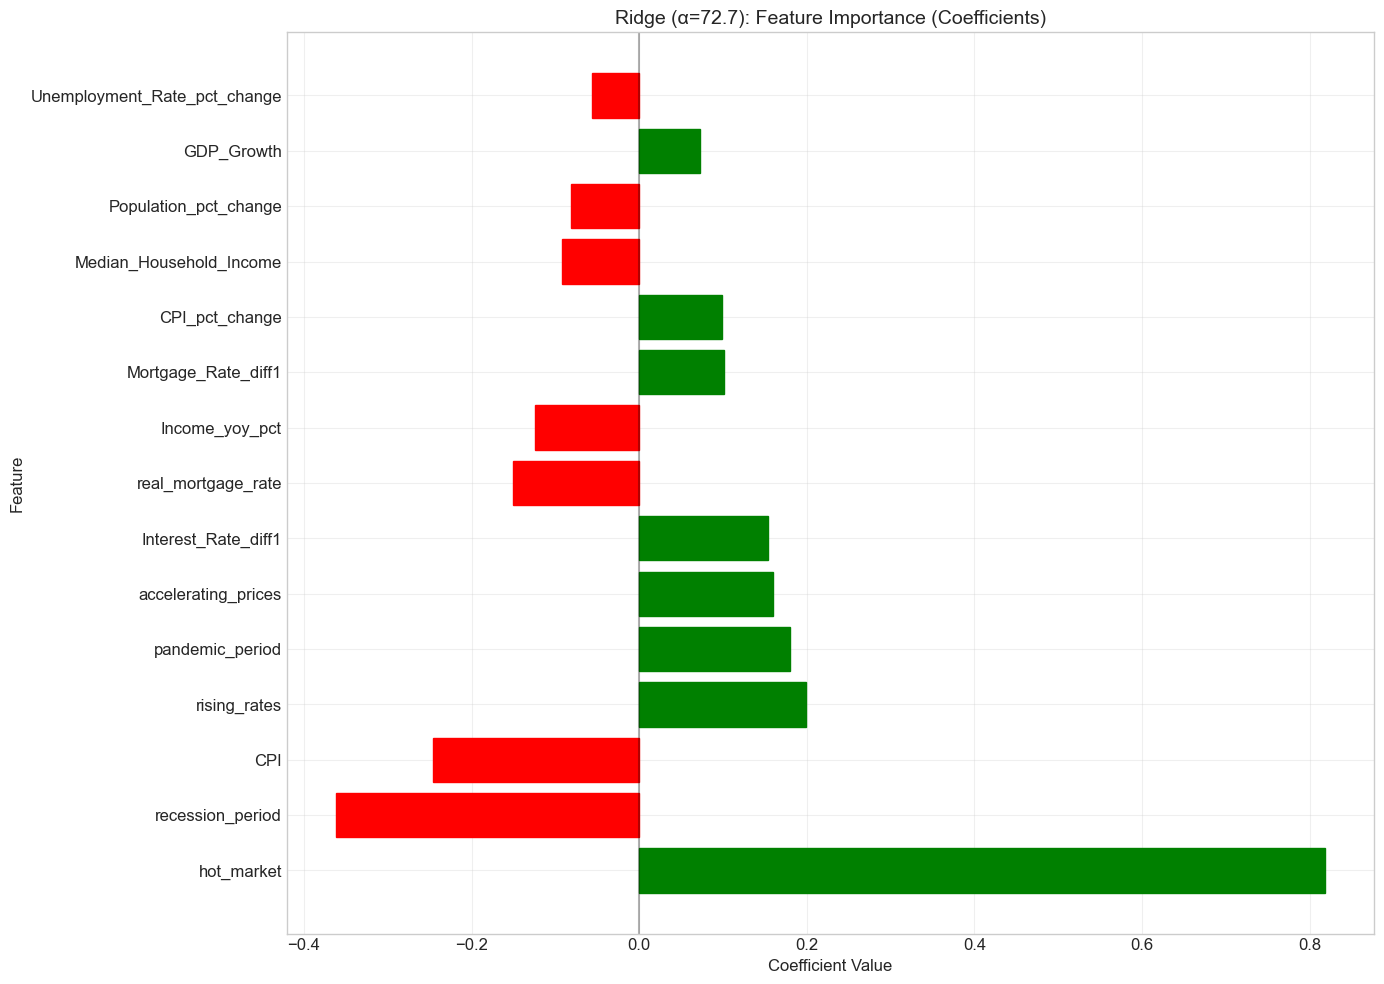

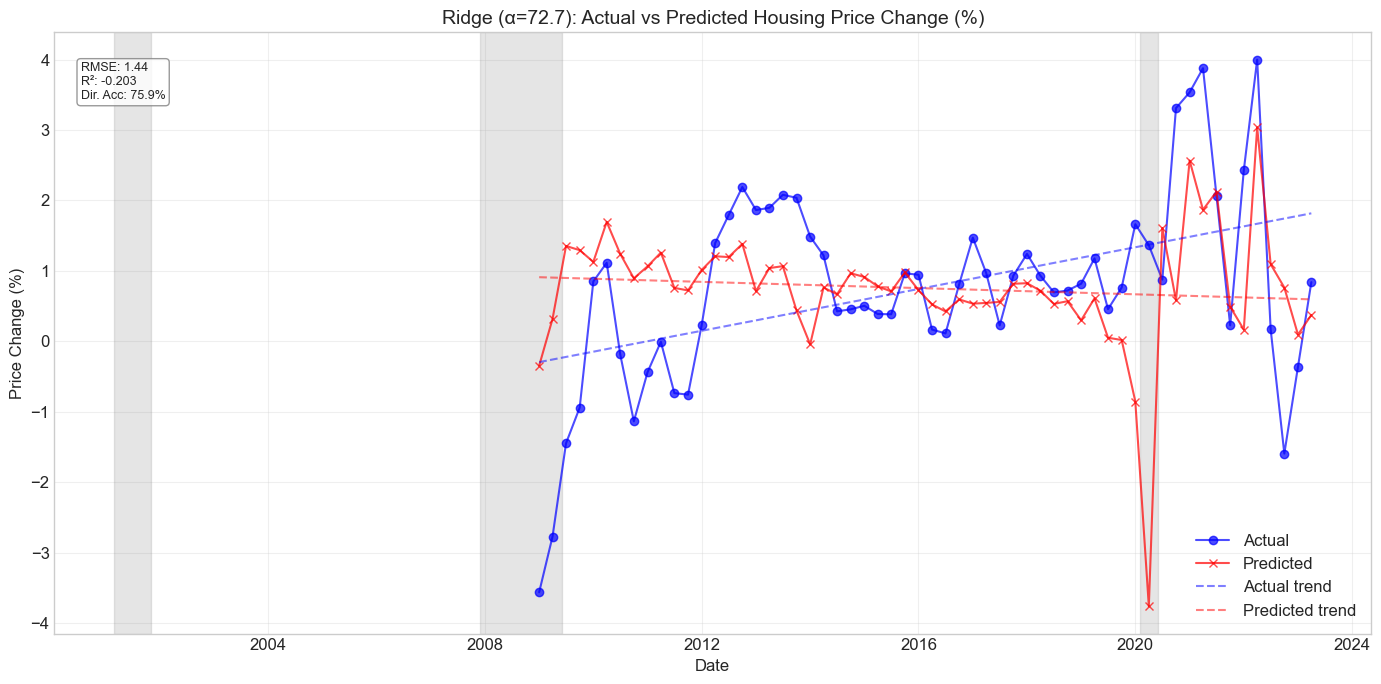

In [68]:
# Create a variable to store all results for later comparison
all_results = {'Linear': {}, 'Tree': {}, 'TimeSeries': {}}

print("\n===== RIDGE REGRESSION =====")
# Set up cross-validation
tscv = TimeSeriesSplit(n_splits=2)

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_clean), columns=X_clean.columns, index=X_clean.index)

# Grid search for Ridge hyperparameters
ridge_params = {'alpha': np.arange(0.1, 100.1, 0.1)}
grid_ridge = GridSearchCV(Ridge(), ridge_params, cv=tscv, scoring='neg_mean_squared_error')
grid_ridge.fit(X_scaled, y_clean)
best_alpha = grid_ridge.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

# Evaluate Ridge model
ridge_model = Ridge(alpha=best_alpha)
ridge_results, ridge_metrics = evaluate_model_with_tscv(ridge_model, X_scaled, y_clean, tscv, "Ridge Regression")

# Get and plot feature importance
ridge_importance = get_feature_importance(Ridge(alpha=best_alpha).fit(X_scaled, y_clean), X_clean, 'linear')
ridge_importance_plot = plot_feature_importance(ridge_importance, f"Ridge (α={best_alpha})", 'linear')
ridge_importance_plot.show()  # Explicitly show the plot

# Plot predictions
ridge_plot = plot_actual_vs_predicted(ridge_results, f"Ridge (α={best_alpha})", ridge_metrics)
ridge_plot.show()  # Explicitly show the plot

# Save results
all_results['Linear']['Ridge'] = {
    'model': ridge_model,
    'params': {'alpha': best_alpha},
    'results': ridge_results,
    'metrics': ridge_metrics,
    'importance': ridge_importance
}


===== LASSO REGRESSION =====
Best alpha: 1.5000000000000002
Lasso Regression Cross-validation Results:
RMSE: 1.22 (±0.20)
MAE: 0.93 (±0.22)
R²: 0.148 (±0.182)
Directional Accuracy: 81.03% (±12.07%)


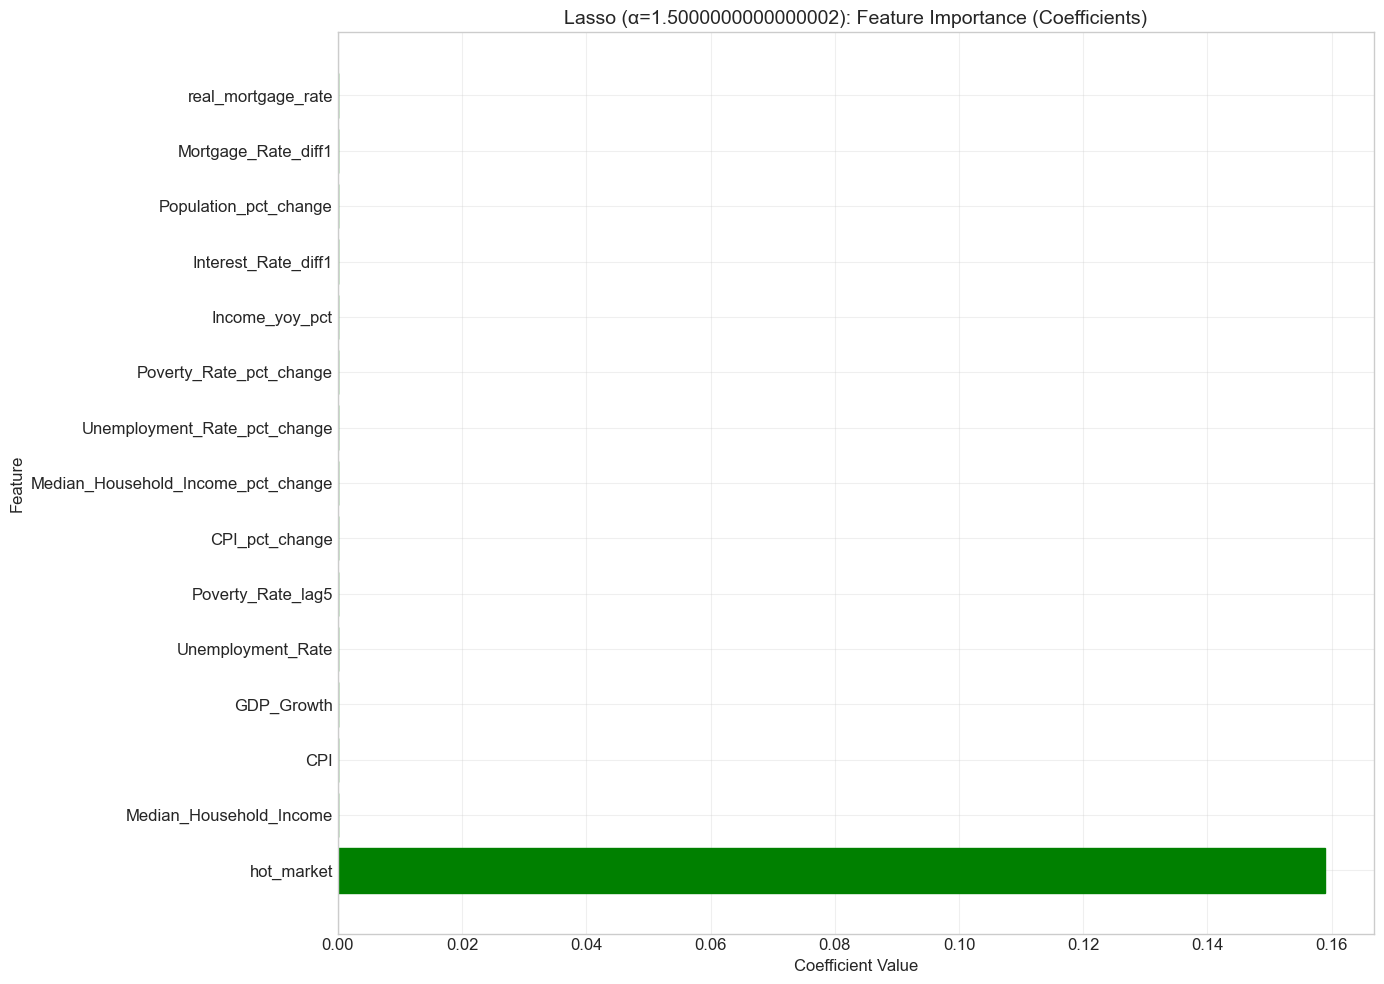

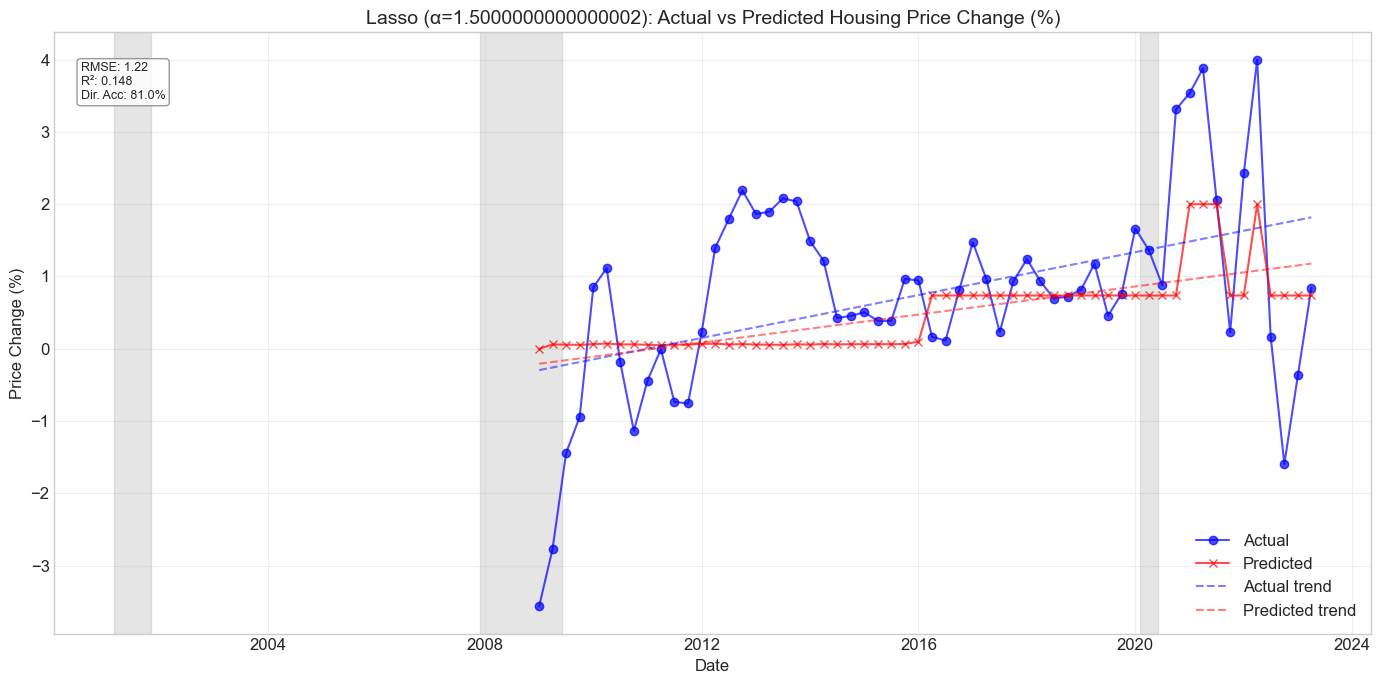

In [69]:
# Do the same for Lasso and ElasticNet
print("\n===== LASSO REGRESSION =====")
# Code for Lasso - similar structure as Ridge
lasso_params = {'alpha': np.arange(0.1, 100.1, 0.1)}
grid_lasso = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=tscv, scoring='neg_mean_squared_error')
grid_lasso.fit(X_scaled, y_clean)
best_lasso_alpha = grid_lasso.best_params_['alpha']
print(f"Best alpha: {best_lasso_alpha}")

lasso_model = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_results, lasso_metrics = evaluate_model_with_tscv(lasso_model, X_scaled, y_clean, tscv, "Lasso Regression")

lasso_importance = get_feature_importance(Lasso(alpha=best_lasso_alpha, max_iter=10000).fit(X_scaled, y_clean), X_clean, 'linear')
lasso_importance_plot = plot_feature_importance(lasso_importance, f"Lasso (α={best_lasso_alpha})", 'linear')
lasso_importance_plot.show()

lasso_plot = plot_actual_vs_predicted(lasso_results, f"Lasso (α={best_lasso_alpha})", lasso_metrics)
lasso_plot.show()

all_results['Linear']['Lasso'] = {
    'model': lasso_model,
    'params': {'alpha': best_lasso_alpha},
    'results': lasso_results,
    'metrics': lasso_metrics,
    'importance': lasso_importance
}

# 4.


===== ELASTIC NET =====


c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.712e+01, tolerance: 3.120e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.905e+01, tolerance: 4.046e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one o

Best parameters: {'alpha': np.int64(1), 'l1_ratio': np.float64(0.5)}
Elastic Net Cross-validation Results:
RMSE: 1.14 (±0.11)
MAE: 0.89 (±0.14)
R²: 0.248 (±0.058)
Directional Accuracy: 81.03% (±8.62%)


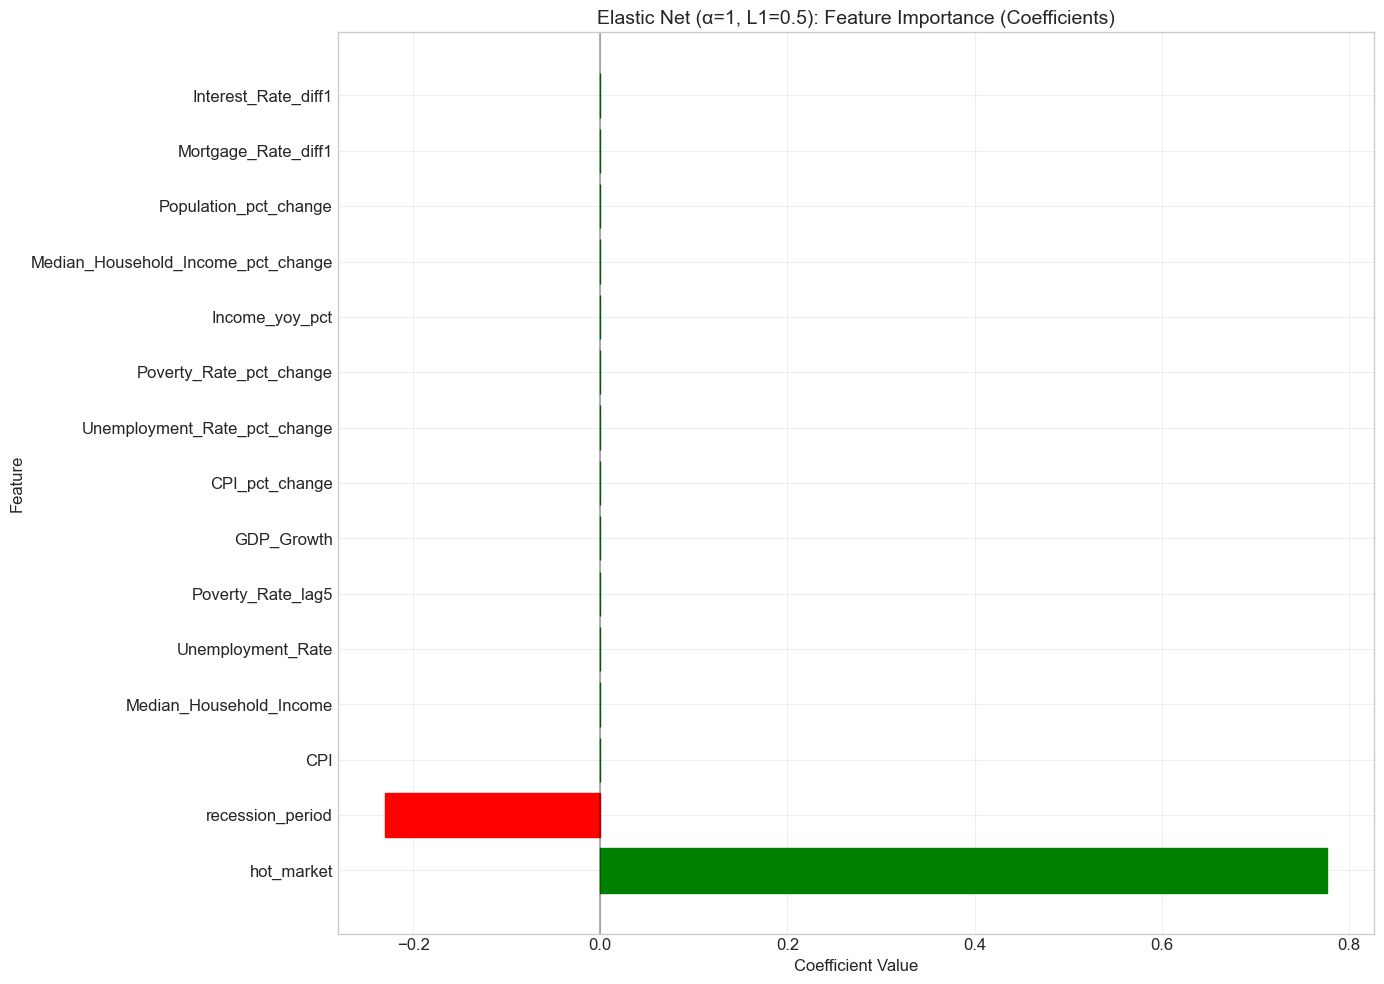

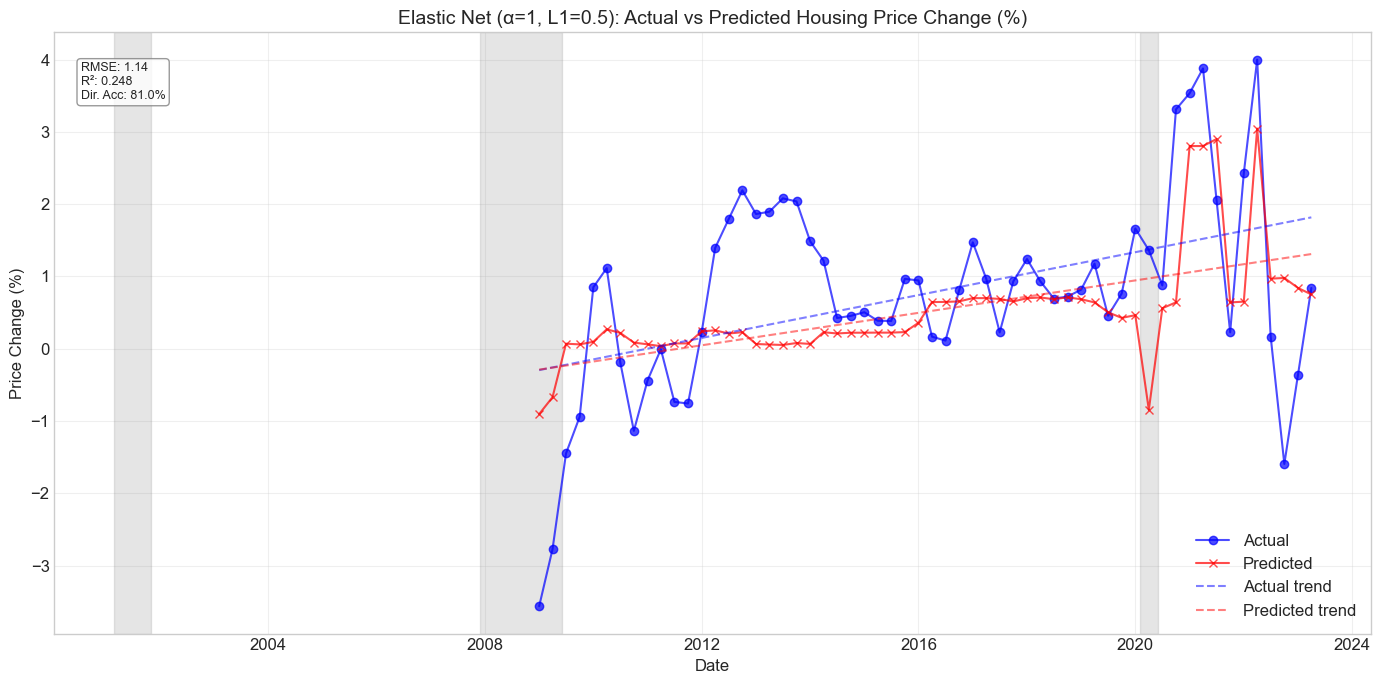

In [70]:
print("\n===== ELASTIC NET =====")
# Code for ElasticNet
enet_params = {
    'alpha': np.arange(1, 101, 1),
    'l1_ratio': np.arange(0.0, 1.1, 0.1)
}
grid_enet = GridSearchCV(ElasticNet(max_iter=10000), enet_params, cv=tscv, scoring='neg_mean_squared_error')
grid_enet.fit(X_scaled, y_clean)
best_enet_params = grid_enet.best_params_
print(f"Best parameters: {best_enet_params}")

enet_model = ElasticNet(alpha=best_enet_params['alpha'], l1_ratio=best_enet_params['l1_ratio'], max_iter=10000)
enet_results, enet_metrics = evaluate_model_with_tscv(enet_model, X_scaled, y_clean, tscv, "Elastic Net")

enet_importance = get_feature_importance(
    ElasticNet(alpha=best_enet_params['alpha'], l1_ratio=best_enet_params['l1_ratio'], max_iter=10000).fit(X_scaled, y_clean),
    X_clean, 'linear'
)
enet_importance_plot = plot_feature_importance(enet_importance, f"Elastic Net (α={best_enet_params['alpha']}, L1={best_enet_params['l1_ratio']})", 'linear')
enet_importance_plot.show()

enet_plot = plot_actual_vs_predicted(enet_results, f"Elastic Net (α={best_enet_params['alpha']}, L1={best_enet_params['l1_ratio']})", enet_metrics)
enet_plot.show()

all_results['Linear']['ElasticNet'] = {
    'model': enet_model,
    'params': best_enet_params,
    'results': enet_results,
    'metrics': enet_metrics,
    'importance': enet_importance
}


===== RIDGE REGRESSION =====
Best alpha: 29.500000000000004
Ridge Regression Cross-validation Results:
RMSE: 1.80 (±0.10)
MAE: 1.28 (±0.11)
R²: -0.674 (±0.491)
Directional Accuracy: 69.70% (±3.03%)


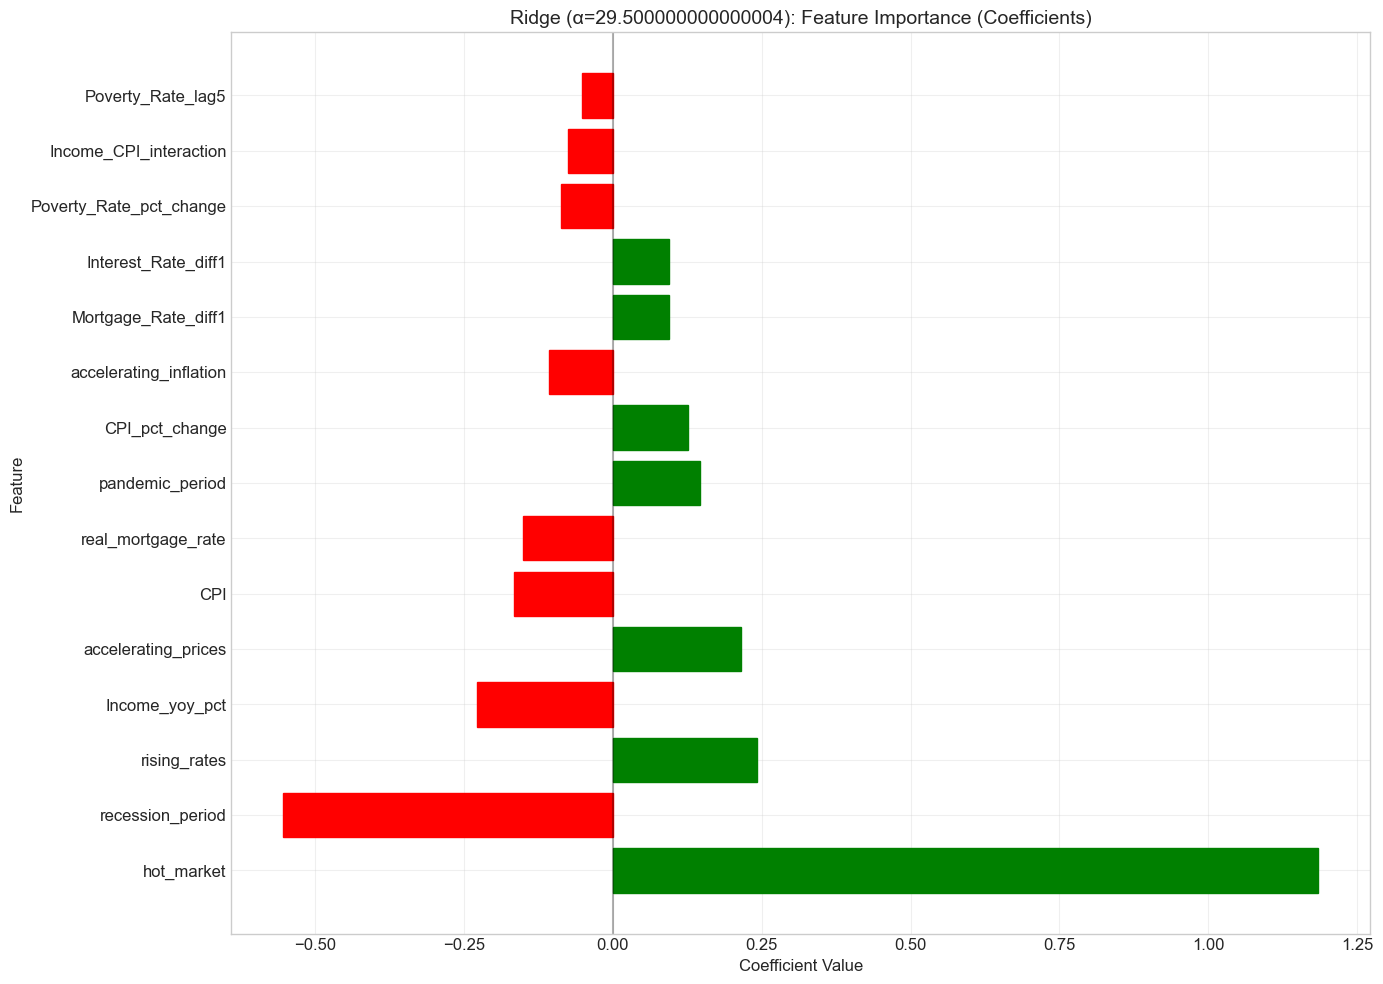

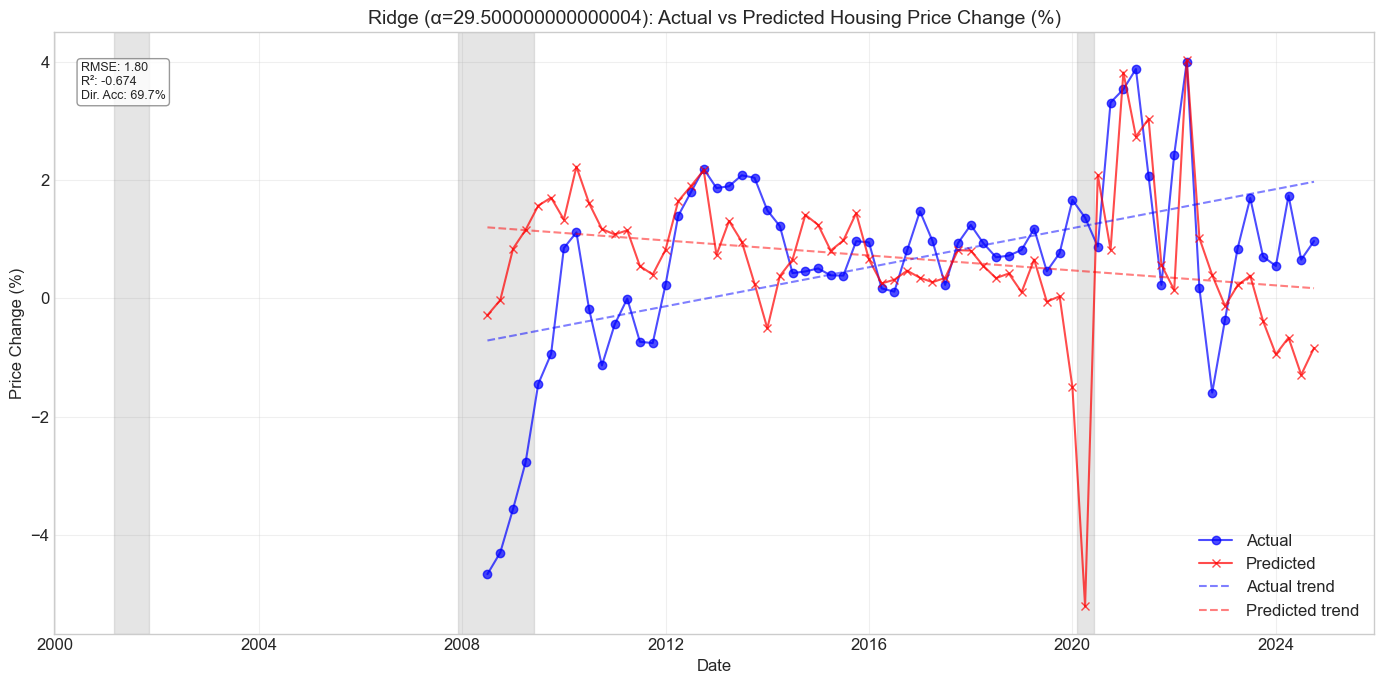

In [71]:
# Create a variable to store all results for later comparison
all_results = {'Linear': {}, 'Tree': {}, 'TimeSeries': {}}

print("\n===== RIDGE REGRESSION =====")
# Set up cross-validation
tscv = TimeSeriesSplit(n_splits=2)

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_partial), columns=X_partial.columns, index=X_partial.index)

# Grid search for Ridge hyperparameters
ridge_params = {'alpha': np.arange(0.1, 100.1, 0.1)}
grid_ridge = GridSearchCV(Ridge(), ridge_params, cv=tscv, scoring='neg_mean_squared_error')
grid_ridge.fit(X_scaled, y_partial)
best_alpha = grid_ridge.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

# Evaluate Ridge model
ridge_model = Ridge(alpha=best_alpha)
ridge_results, ridge_metrics = evaluate_model_with_tscv(ridge_model, X_scaled, y_partial, tscv, "Ridge Regression")

# Get and plot feature importance
ridge_importance = get_feature_importance(Ridge(alpha=best_alpha).fit(X_scaled, y_partial), X_partial, 'linear')
ridge_importance_plot = plot_feature_importance(ridge_importance, f"Ridge (α={best_alpha})", 'linear')
ridge_importance_plot.show()  # Explicitly show the plot

# Plot predictions
ridge_plot = plot_actual_vs_predicted(ridge_results, f"Ridge (α={best_alpha})", ridge_metrics)
ridge_plot.show()  # Explicitly show the plot

# Save results
all_results['Linear']['Ridge'] = {
    'model': ridge_model,
    'params': {'alpha': best_alpha},
    'results': ridge_results,
    'metrics': ridge_metrics,
    'importance': ridge_importance
}


===== LASSO REGRESSION =====
Best alpha: 0.5
Lasso Regression Cross-validation Results:
RMSE: 1.31 (±0.28)
MAE: 0.96 (±0.23)
R²: 0.182 (±0.023)
Directional Accuracy: 80.30% (±10.61%)


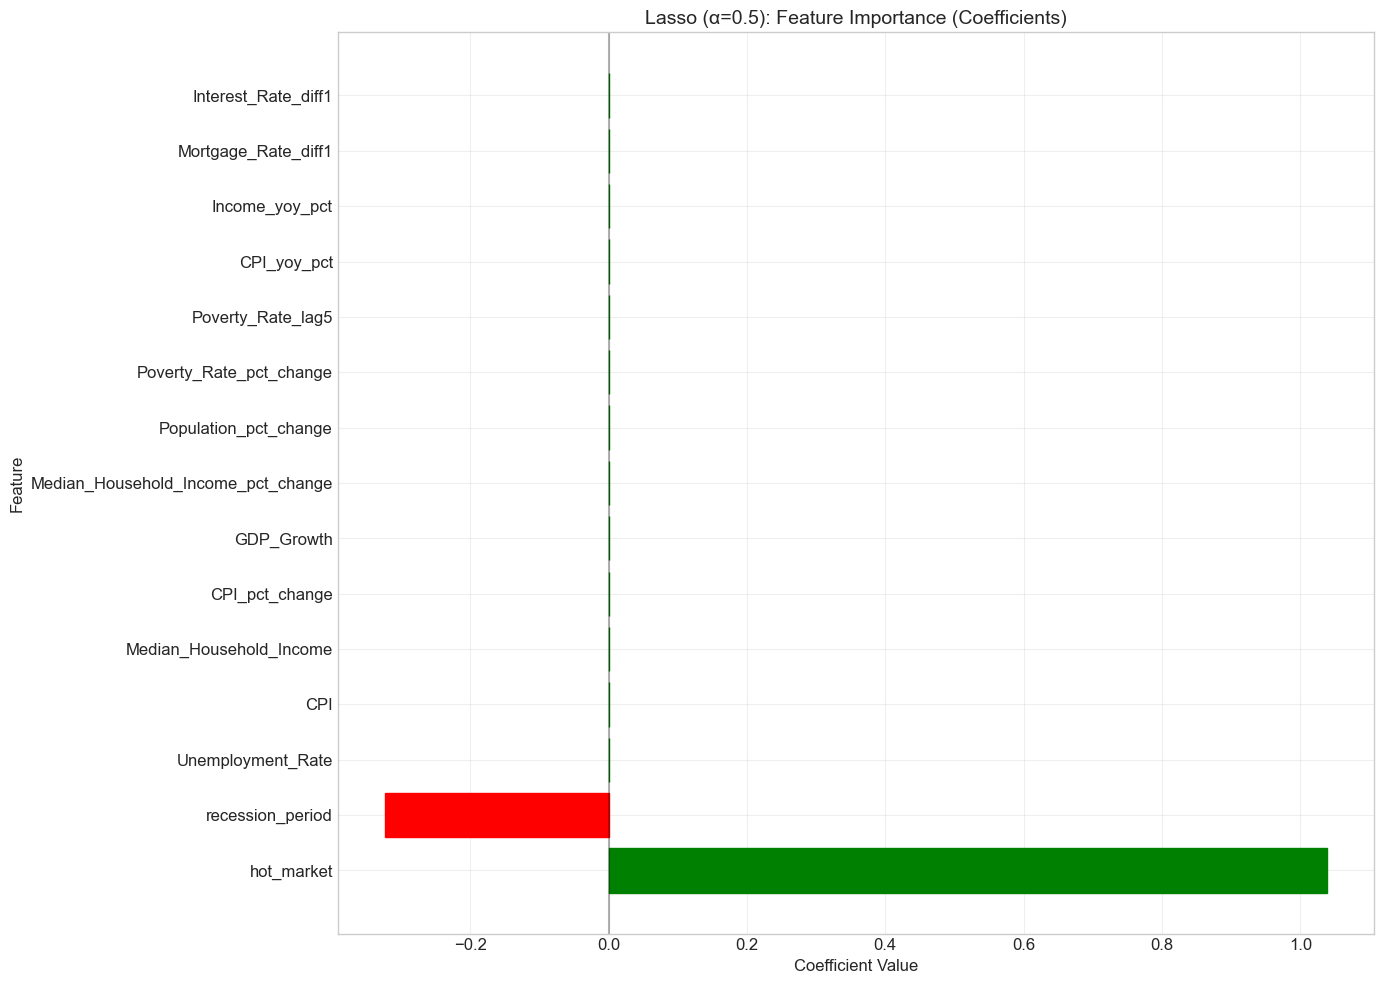

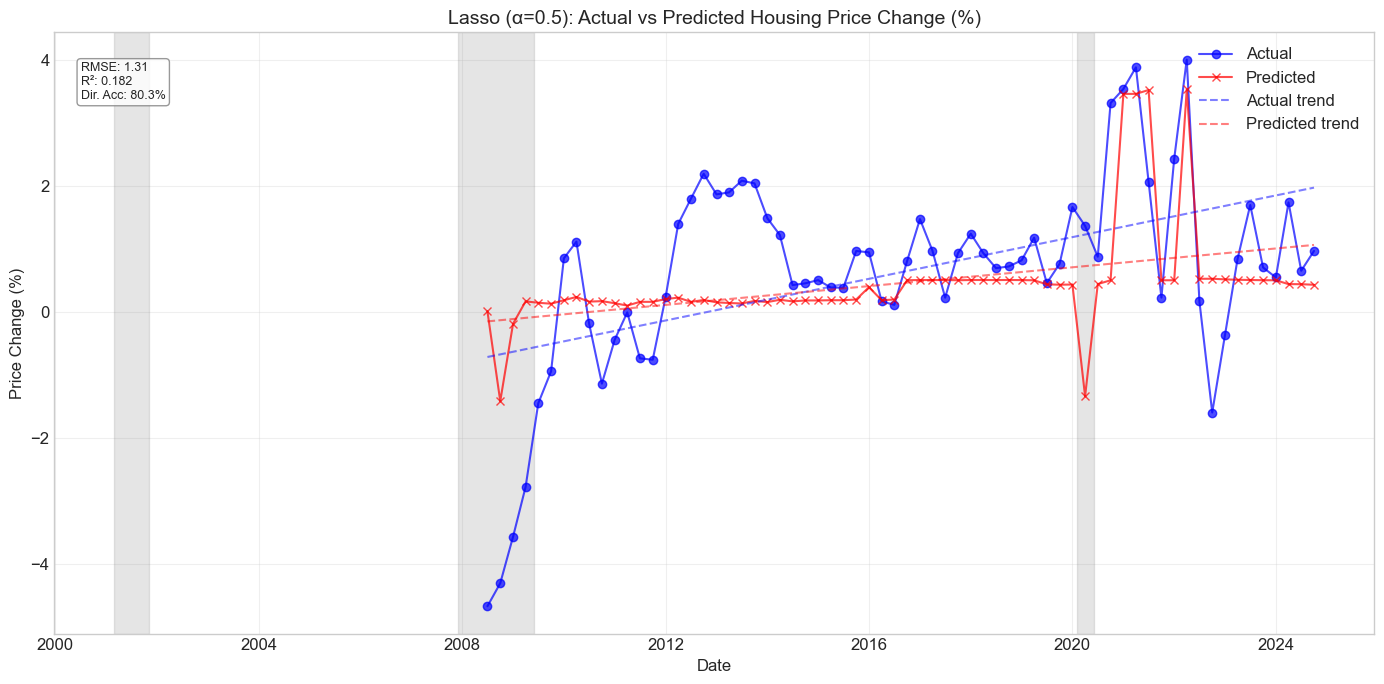

In [72]:
# Do the same for Lasso and ElasticNet
print("\n===== LASSO REGRESSION =====")
# Code for Lasso - similar structure as Ridge
lasso_params = {'alpha': np.arange(0.1, 100.1, 0.1)}
grid_lasso = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=tscv, scoring='neg_mean_squared_error')
grid_lasso.fit(X_scaled, y_partial)
best_lasso_alpha = grid_lasso.best_params_['alpha']
print(f"Best alpha: {best_lasso_alpha}")

lasso_model = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_results, lasso_metrics = evaluate_model_with_tscv(lasso_model, X_scaled, y_partial, tscv, "Lasso Regression")

lasso_importance = get_feature_importance(Lasso(alpha=best_lasso_alpha, max_iter=10000).fit(X_scaled, y_partial), X_partial, 'linear')
lasso_importance_plot = plot_feature_importance(lasso_importance, f"Lasso (α={best_lasso_alpha})", 'linear')
lasso_importance_plot.show()

lasso_plot = plot_actual_vs_predicted(lasso_results, f"Lasso (α={best_lasso_alpha})", lasso_metrics)
lasso_plot.show()

all_results['Linear']['Lasso'] = {
    'model': lasso_model,
    'params': {'alpha': best_lasso_alpha},
    'results': lasso_results,
    'metrics': lasso_metrics,
    'importance': lasso_importance
}


===== ELASTIC NET =====


c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.369e+01, tolerance: 2.282e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.240e+01, tolerance: 4.113e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one o

Best parameters: {'alpha': np.float64(0.5), 'l1_ratio': np.float64(1.0)}
Elastic Net Cross-validation Results:
RMSE: 1.31 (±0.28)
MAE: 0.96 (±0.23)
R²: 0.182 (±0.023)
Directional Accuracy: 80.30% (±10.61%)


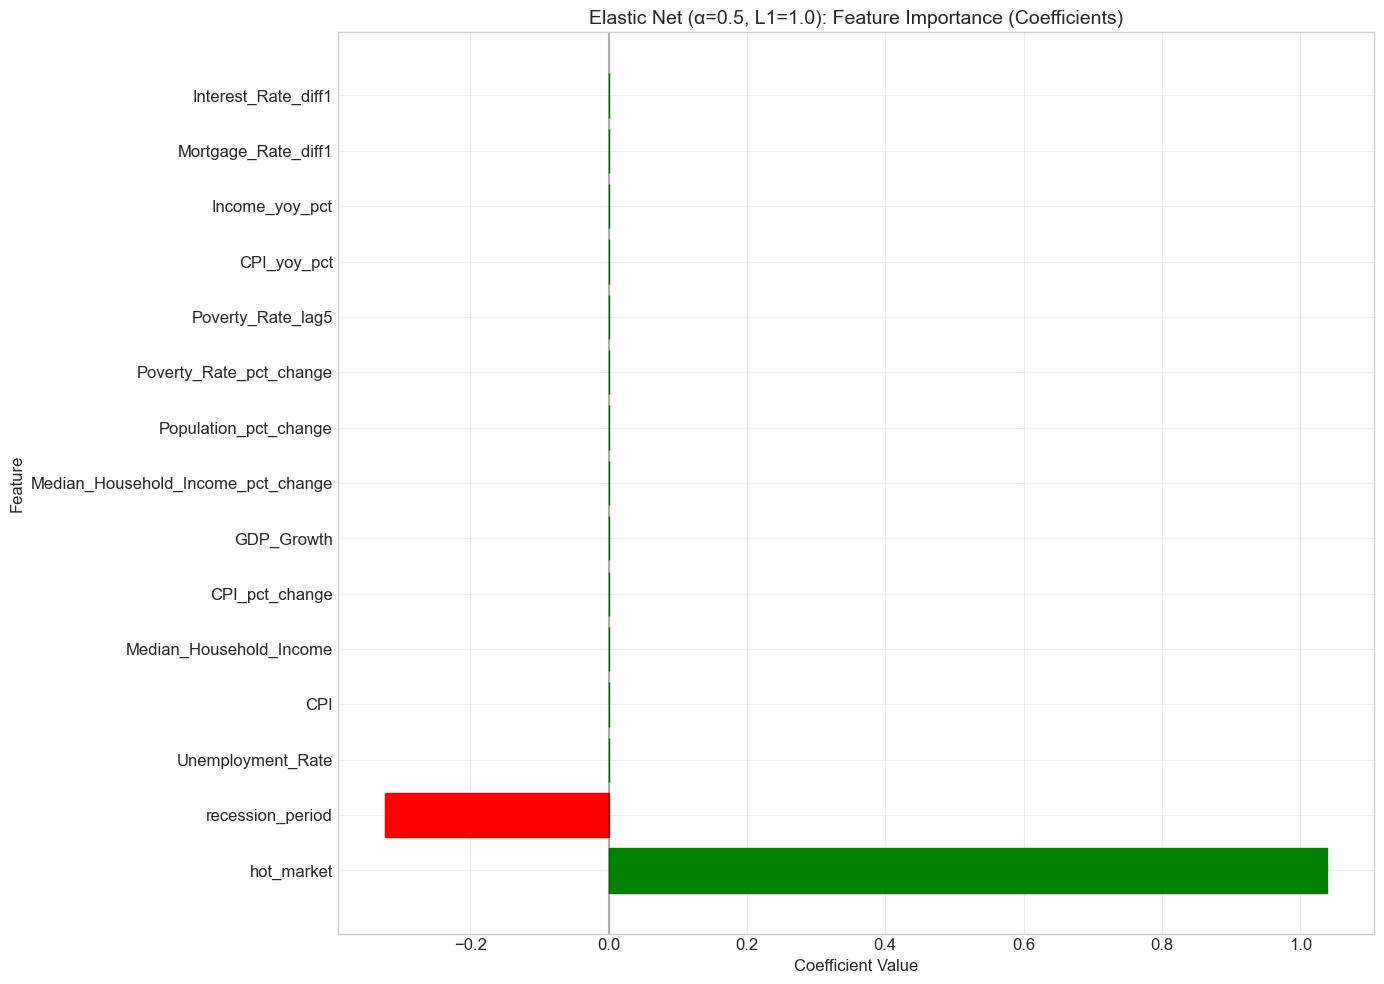

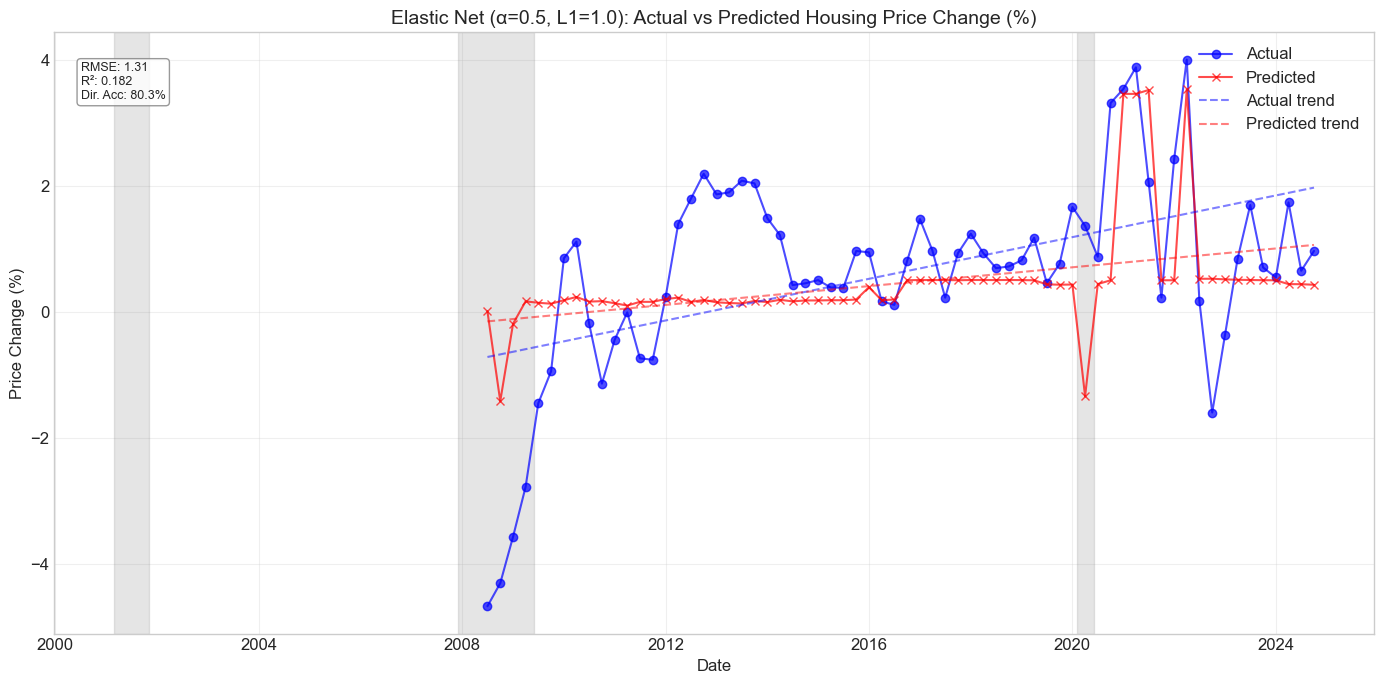

In [64]:
print("\n===== ELASTIC NET =====")
# Code for ElasticNet
enet_params = {
    'alpha': np.arange(0.1, 100.1, 0.1),
    'l1_ratio': np.arange(0.0, 1.1, 0.1)
}
grid_enet = GridSearchCV(ElasticNet(max_iter=10000), enet_params, cv=tscv, scoring='neg_mean_squared_error')
grid_enet.fit(X_scaled, y_partial)
best_enet_params = grid_enet.best_params_
print(f"Best parameters: {best_enet_params}")

enet_model = ElasticNet(alpha=best_enet_params['alpha'], l1_ratio=best_enet_params['l1_ratio'], max_iter=10000)
enet_results, enet_metrics = evaluate_model_with_tscv(enet_model, X_scaled, y_partial, tscv, "Elastic Net")

enet_importance = get_feature_importance(
    ElasticNet(alpha=best_enet_params['alpha'], l1_ratio=best_enet_params['l1_ratio'], max_iter=10000).fit(X_scaled, y_partial),
    X_partial, 'linear'
)
enet_importance_plot = plot_feature_importance(enet_importance, f"Elastic Net (α={best_enet_params['alpha']}, L1={best_enet_params['l1_ratio']})", 'linear')
enet_importance_plot.show()

enet_plot = plot_actual_vs_predicted(enet_results, f"Elastic Net (α={best_enet_params['alpha']}, L1={best_enet_params['l1_ratio']})", enet_metrics)
enet_plot.show()

all_results['Linear']['ElasticNet'] = {
    'model': enet_model,
    'params': best_enet_params,
    'results': enet_results,
    'metrics': enet_metrics,
    'importance': enet_importance
}